# 2 · TF-activity spatial maps along the fate axis

Infer per-cell **TF activity** (decoupler ULM over CollecTRI) and visualize the top intrinsic ingredients spatially and against the **fate axis** (0 = progenitor → 1 = committed).

In [1]:
import sys, warnings
warnings.filterwarnings("ignore")
sys.path.insert(0, ".")  # so `_pipeline` is importable when run from cookbook/
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
import stereo_fate as sf
from _pipeline import build_result, TARGET_FATE, PROGENITOR
from pathlib import Path
FIG = Path("..") / "figures"; FIG.mkdir(exist_ok=True)
sns.set_context("talk")
# STANDING REQUIREMENT: resource guard first.
sf.check_resources(verbose=True)


stereo-fate resource check
  total RAM      :   62.9 GB
  available RAM  :    4.0 GB
  cpu_count      : 16
  n_jobs (capped): 15


ResourceReport(total_ram_gb=62.87113571166992, available_ram_gb=4.043811798095703, cpu_count=16, n_jobs=15, est_dense_gb=None, fraction_of_available=None, safe=True, recommendation='ok')

In [2]:
adata = build_result()
rank = adata.uns['stereo_fate']['tf_ranking']
rank.head(10)[['rank','tf','spearman','effect_size','fdr']]

stereo-fate resource check
  total RAM      :   62.9 GB
  available RAM  :    4.0 GB
  cpu_count      : 16
  n_jobs (capped): 15


,rank,tf,spearman,effect_size,fdr
0,1,Isl1,0.462357,2.007365,0.0
1,2,Hand2,0.386379,1.952261,0.0
2,3,Nkx2-5,0.391006,1.938423,0.0
3,4,Tbx20,0.385019,1.893563,0.0
4,5,Tbx5,0.374804,1.879857,0.0
5,6,Mef2c,0.382849,1.800356,0.0
6,7,Gata4,0.364798,1.741712,0.0
7,8,Hand1,0.373887,1.720539,0.0
8,9,Gata6,0.340703,1.668068,0.0
9,10,Srf,0.306009,1.625379,0.0


### Fate axis in space, and the top fate-rising TFs

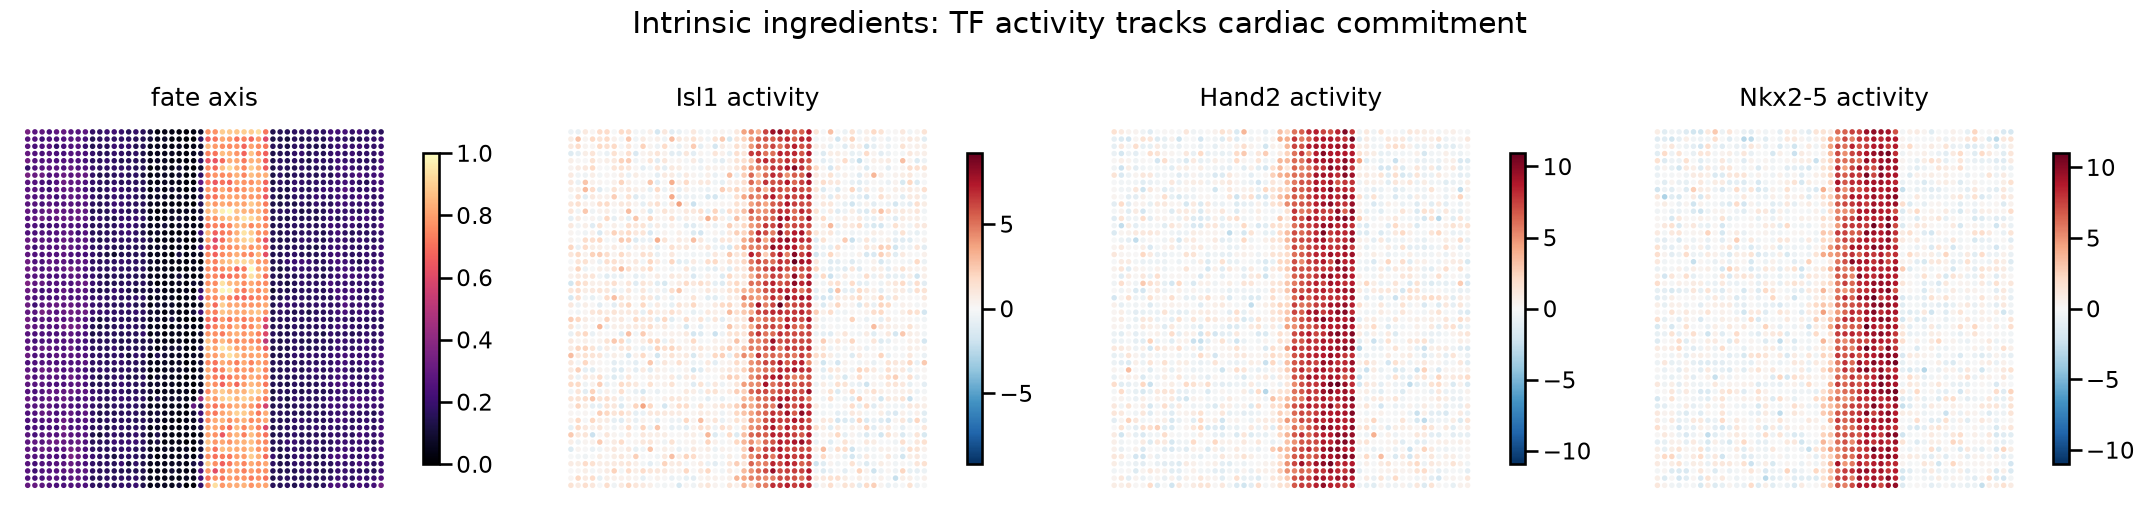

In [3]:
xy = adata.obsm['spatial']
acts = adata.obsm['tf_activity']
top_tfs = list(rank['tf'].head(3))
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
s0=axes[0].scatter(xy[:,0],xy[:,1],c=adata.obs['fate_axis'],cmap='magma',s=6)
axes[0].set_title('fate axis'); plt.colorbar(s0,ax=axes[0],shrink=.8)
for ax,tf in zip(axes[1:], top_tfs):
    v=acts[tf].values
    sc=ax.scatter(xy[:,0],xy[:,1],c=v,cmap='RdBu_r',vmin=-np.abs(v).max(),vmax=np.abs(v).max(),s=6)
    ax.set_title(f'{tf} activity'); plt.colorbar(sc,ax=ax,shrink=.8)
for ax in axes: ax.set_aspect('equal'); ax.invert_yaxis(); ax.axis('off')
fig.suptitle('Intrinsic ingredients: TF activity tracks cardiac commitment', y=1.04)
fig.tight_layout(); fig.savefig(FIG/'02_tf_activity_maps.png', dpi=150, bbox_inches='tight')
plt.show()

### Activity vs the fate axis (the ranking criterion)

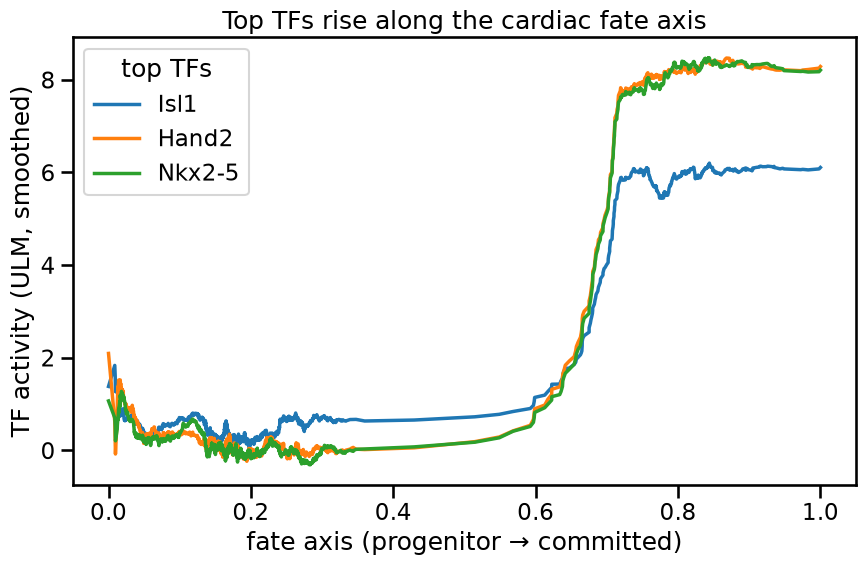

In [4]:
fig, ax = plt.subplots(figsize=(9,6))
fa = adata.obs['fate_axis'].values
for tf in top_tfs:
    order=np.argsort(fa)
    y=pd.Series(acts[tf].values[order]).rolling(80,min_periods=1).mean()
    ax.plot(np.sort(fa), y, label=tf, lw=2.5)
ax.set_xlabel('fate axis (progenitor → committed)'); ax.set_ylabel('TF activity (ULM, smoothed)')
ax.legend(title='top TFs'); ax.set_title('Top TFs rise along the cardiac fate axis')
fig.tight_layout(); fig.savefig(FIG/'02b_tf_activity_vs_fate.png', dpi=150, bbox_inches='tight'); plt.show()